In [10]:
#  GLOBAL GREENHOUSE GAS EMISSIONS ANALYSIS

In [11]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [12]:
# Loading Data

df = pd.read_csv("emissioni-gas-serra-globali-per-paese-1950-2024.csv")

print(df.head())
print(df.info())

       country  year iso_code  total_ghg  ghg_per_capita
0  Afghanistan  1950      AFG  19.868742        2.555078
1  Afghanistan  1951      AFG  21.069101        2.673967
2  Afghanistan  1952      AFG  22.094320        2.766014
3  Afghanistan  1953      AFG  23.255630        2.872235
4  Afghanistan  1954      AFG  24.250988        2.954572
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14925 entries, 0 to 14924
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         14925 non-null  object 
 1   year            14925 non-null  int64  
 2   iso_code        14925 non-null  object 
 3   total_ghg       14475 non-null  float64
 4   ghg_per_capita  14475 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 583.1+ KB
None


In [13]:
# Data Cleaning

# checking missing values

print(df.isnull().sum())

country             0
year                0
iso_code            0
total_ghg         450
ghg_per_capita    450
dtype: int64


In [14]:
# Creating Output Folder

output_folder = "plots_output"
os.makedirs(output_folder, exist_ok=True)

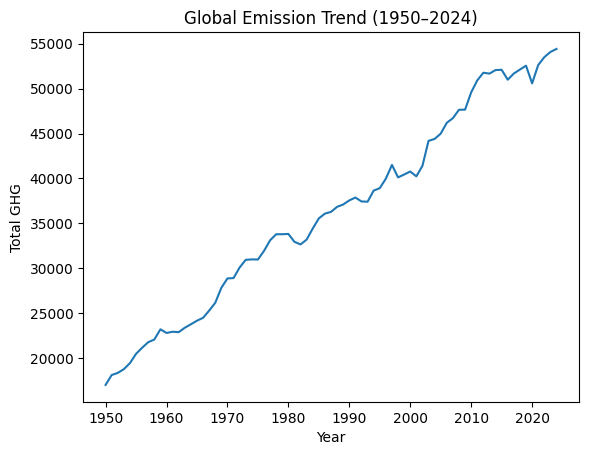

In [15]:
# Global Emission Trend

global_trend = df.groupby("year")["total_ghg"].sum()

plt.figure()

plt.plot(global_trend)

plt.title("Global Emission Trend (1950–2024)")

plt.xlabel("Year")

plt.ylabel("Total GHG")

plt.savefig(f"{output_folder}/global_trend.png")

plt.show()

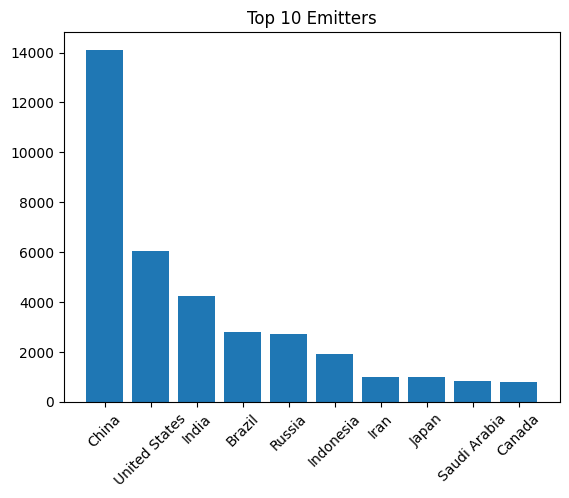

In [16]:
# Top 10 Countries in Latest Year

latest_year = df["year"].max()

top10 = df[df["year"] == latest_year] \
        .sort_values(by="total_ghg", ascending=False) \
        .head(10)

plt.figure()

plt.bar(top10["country"], top10["total_ghg"])

plt.xticks(rotation=45)

plt.title("Top 10 Emitters")

plt.savefig(f"{output_folder}/top10_emitters.png")

plt.show()

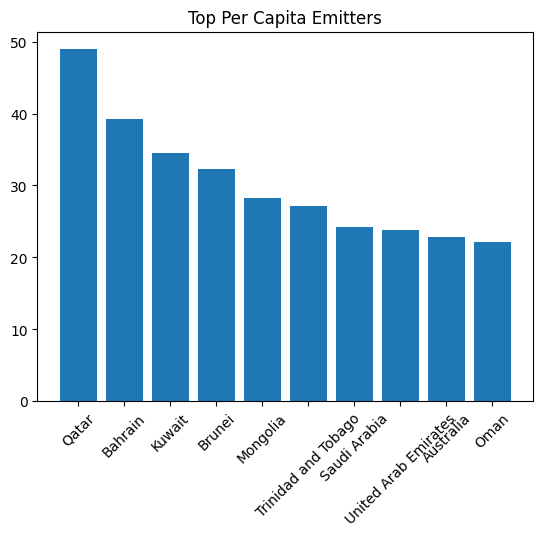

In [18]:
# Countries with Highest Emisssion per Person (Per Capita)

top_pc = df[df["year"] == latest_year] \
        .sort_values(by="ghg_per_capita", ascending=False) \
        .head(10)

plt.figure()

plt.bar(top_pc["country"], top_pc["ghg_per_capita"])

plt.xticks(rotation=45)

plt.title("Top Per Capita Emitters")

plt.savefig(f"{output_folder}/top_per_capita.png")

plt.show()


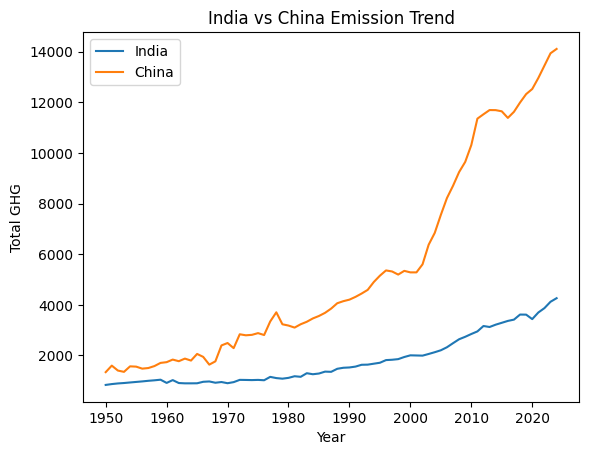

In [21]:
# Multi-nation Trend Comparison


india = df[df["country"] == "India"]
china = df[df["country"] == "China"]


plt.figure()
plt.plot(india["year"], india["total_ghg"], label="India")
plt.plot(china["year"], china["total_ghg"], label="China")


plt.title("India vs China Emission Trend")
plt.xlabel("Year")
plt.ylabel("Total GHG")
plt.legend()

plt.savefig(f"{output_folder}/india_vs_china.png")
plt.show()


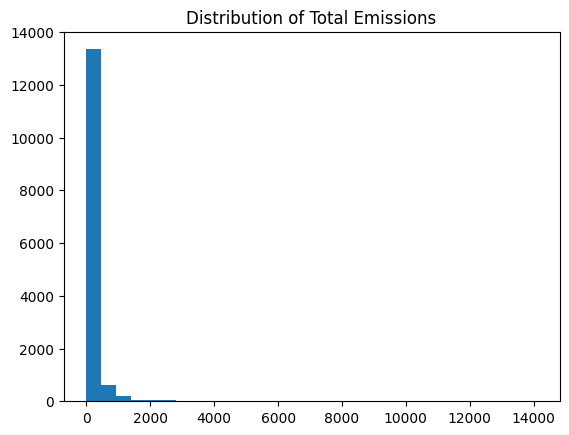

In [22]:
# Distribution Analysis

plt.figure()

plt.hist(df["total_ghg"], bins=30)

plt.title("Distribution of Total Emissions")

plt.savefig(f"{output_folder}/distribution.png")

plt.show()

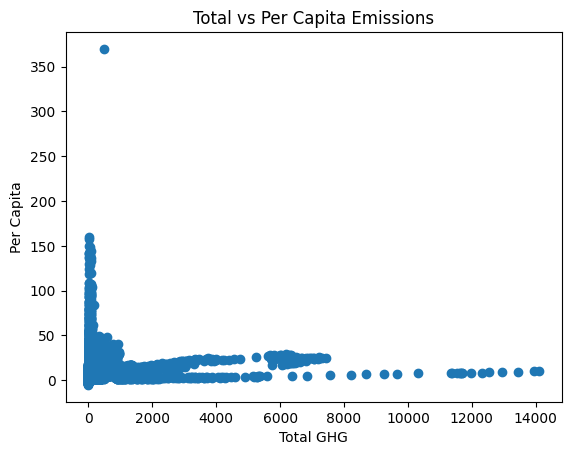

In [23]:
# Correlation Analysis

plt.figure()

plt.scatter(df["total_ghg"], df["ghg_per_capita"])

plt.title("Total vs Per Capita Emissions")

plt.xlabel("Total GHG")

plt.ylabel("Per Capita")

plt.savefig(f"{output_folder}/correlation.png")

plt.show()

/tmp/ipykernel_2133/902077310.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["ghg_growth"] = df.groupby("country")["total_ghg"].pct_change()


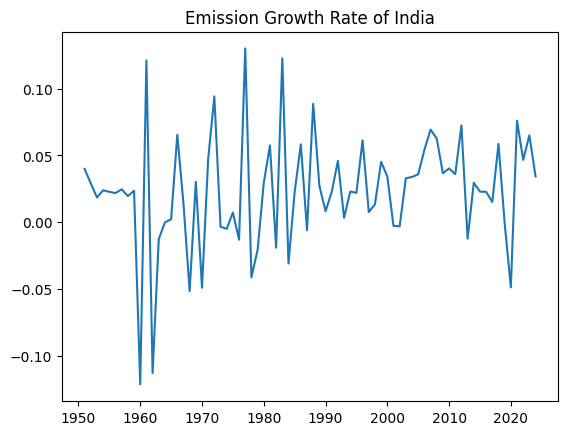

In [25]:
# Growth Analysis

# calculating year-over-year growth

df["ghg_growth"] = df.groupby("country")["total_ghg"].pct_change()

growth_sample = df[df["country"] == "India"]

plt.figure()
plt.plot(growth_sample["year"], growth_sample["ghg_growth"])

plt.title("Emission Growth Rate of India")

plt.savefig(f"{output_folder}/growth_rate.png")

plt.show()

In [26]:
# Top Growing Countries

latest_year = df["year"].max()

latest_data = df[df["year"] == latest_year]

top_countries = latest_data.sort_values(by="total_ghg", ascending=False).head(10)

print(top_countries[["country", "total_ghg"]])

             country     total_ghg
2699           China  14107.006836
14249  United States   6054.308105
5924           India   4262.410645
1799          Brazil   2804.430664
11024         Russia   2729.234619
5999       Indonesia   1902.534790
6074            Iran   1012.216431
6524           Japan   1007.159180
11624   Saudi Arabia    821.838501
2324          Canada    802.732178


In [27]:
print(" Python Project. All plots saved in:", output_folder)

 Python Project. All plots saved in: plots_output
